# D3. Curve-number change and methodological uncertainty

This validation record evaluates a seven-year curve-number trajectory for Difficult Run near Great Falls, Virginia. It was executed on 6 August 2026 with `cnkit` 1.1.0, a registered Earth Engine project, USGS watershed delineation, Annual NLCD, and Soil Data Access.

Each year uses the same watershed, soil source, lookup implementation, and reporting schema. The analysis reports the fair-condition trajectory together with the poor-to-good condition range, runoff estimate, unmapped area, and data provenance. The reference sequence generally completes in two to five minutes.

The executed outputs below support the trajectory and uncertainty comparisons reported in the workshop materials.


In [1]:
# Portable setup: works in Colab, JupyterLab, JupyterHub and VS Code.
import importlib
import subprocess
import sys

CNKIT_EXAMPLE_VERSION = "1.1.0"

try:
    import cnkit as _cnkit_setup
    import ee as _ee_setup
    import matplotlib as _matplotlib_setup
except ImportError:
    _cnkit_setup = None

if getattr(_cnkit_setup, "__version__", None) != CNKIT_EXAMPLE_VERSION:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "--quiet",
                           "cnkit[gee]==" + CNKIT_EXAMPLE_VERSION,
                           "matplotlib>=3.5"])
    importlib.invalidate_caches()
    for _name in list(sys.modules):
        if _name == "cnkit" or _name.startswith("cnkit."):
            sys.modules.pop(_name, None)

print("cnkit Earth Engine environment ready")

cnkit Earth Engine environment ready


In [2]:
import os
from getpass import getpass

# Runtime input keeps the project id out of notebook source and Git history.
EE_PROJECT = (os.environ.get("CNKIT_EE_PROJECT") or
              getpass("Earth Engine project id: "))

import ee
ee.Authenticate()

Earth Engine project id: ··········


In [3]:
import json
import warnings

import matplotlib.pyplot as plt

import cnkit
from cnkit.workflows import cn_trajectory

#: Difficult Run near Great Falls, VA. USGS gage 01646000, 57.8 square miles.
LAT, LON = 38.97594, -77.24581

#: NOAA Atlas 14 Volume 2 Version 3.0, ten year twenty four hour point depth
#: at the gage coordinate.
DESIGN_DEPTH_IN = 4.78

#: Every third year. Change to range(1985, 2026) for the current full mirror,
#: query available years first, and read the cost note at the top.
YEARS = list(range(2001, 2020, 3))

print("cnkit", cnkit.__version__, "| years", YEARS)

cnkit 1.1.0 | years [2001, 2004, 2007, 2010, 2013, 2016, 2019]


## The whole thing, in one call

`cn_trajectory` chains everything the other two notebooks did. Given a pour
point it delineates against USGS, binds the polygon to an Earth Engine session,
crosses land cover with soils pixel by pixel for each year, and hands each
year's area table to `cnkit.lookup.composite_from_areas`. No hydrology is
implemented in `cnkit.workflows` and no curve number arithmetic happens there.

Two things about the signature are deliberate.

`soils=` is required, for the reason notebook 2 spent a section on. And the
condition spread is **not** optional, not behind a flag and not a separate call
you might skip. It comes back every time, because a trajectory published
without it reproduces exactly the error this library exists to correct.

Expect: a short delineation pause with no Earth Engine involvement, then one
progress line per year. Expect the trajectory to run from about **75.15 in 2001
to about 75.50 in 2019**, and expect `requests_issued` to be **eight**, one per
year plus the year listing, against `requests_served_from_cache` of
**fourteen**, which is the two extra conditions in each of the seven years.

In [4]:
with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter("always")
    traj = cn_trajectory(
        lat=LAT, lon=LON, project=EE_PROJECT,
        years=YEARS, condition="fair", soils="sda",
        design_depth_in=DESIGN_DEPTH_IN,
        progress=lambda done, total, year: print("  %d of %d: %d"
                                                 % (done, total, year)),
    )

print()
print(traj)

  1 of 7: 2001
  2 of 7: 2004
  3 of 7: 2007
  4 of 7: 2010
  5 of 7: 2013
  6 of 7: 2016
  7 of 7: 2019

CnTrajectory(2001 to 2019, 7 years, CN 75.49 to 75.78, condition spread 8.45, ratio 29.4)


In [5]:
for entry in caught:
    print("%s: %s\n" % (entry.category.__name__, str(entry.message)[:220]))

`to_frame` puts everything on one index, which is what you would write to CSV.
The `spread` column is `poor - good`.

Expect seven rows, `cn` sitting between `good` and `poor` in every one of them,
`spread` around 7.4 throughout, and `unmapped_pct` around ten percent and not
zero: SSURGO maps urban land, made land, pits and open water with no hydrologic
soil group at all.

In [6]:
frame = traj.to_frame()
frame.round(4)

,cn,poor,fair,good,spread,unmapped_pct,runoff_in
year,,,,,,,
2001,75.4914,80.4586,75.4914,71.8492,8.6094,21.2655,2.3129
2004,75.5693,80.4690,75.5693,71.9757,8.4933,21.2655,2.3194
2007,75.6357,80.5020,75.6357,72.0672,8.4348,21.2655,2.3249
2010,75.6826,80.5198,75.6826,72.1359,8.3839,21.2655,2.3288
2013,75.7123,80.5587,75.7123,72.1598,8.3989,21.2655,2.3313
2016,75.7491,80.5994,75.7491,72.1948,8.4046,21.2655,2.3344
2019,75.7790,80.6309,75.7790,72.2245,8.4064,21.2655,2.3369


## The three numbers

`landcover_change_cn` is last year minus first year: the measured signal.
`mean_condition_spread` is the mean of the poor to good spread: the assumption.
`spread_to_change_ratio` is the second divided by the absolute value of the
first, and it is carried on the result as a number so that nobody has to
remember to make the comparison.

Expect a change of about **+0.34**, a spread of about **7.43**, and a ratio
around **22**.

In [7]:
print("composite CN %s          %8.4f" % (frame.index[0], traj.composite_cn.iloc[0]))
print("composite CN %s          %8.4f" % (frame.index[-1], traj.composite_cn.iloc[-1]))
print("measured change              %+8.4f curve numbers" % traj.landcover_change_cn)
print("mean condition spread        %8.4f curve numbers" % traj.mean_condition_spread)
print("ratio, assumption to signal  %8.1f" % traj.spread_to_change_ratio)
print()
print(traj.summary())

composite CN 2001           75.4914
composite CN 2019           75.7790
measured change               +0.2876 curve numbers
mean condition spread          8.4473 curve numbers
ratio, assumption to signal      29.4

Composite curve number 75.49 in 2001 to 75.78 in 2019, a change of +0.29 units. The hydrologic condition assumption over the same basin is worth 8.45 units, which is 29.4 times the measured change. The condition cannot be observed from imagery; report both or report neither.


## First, the plot everybody draws

The trajectory on its own, autoscaled, which is what a plotting library does by
default and what almost every published version of this figure looks like.

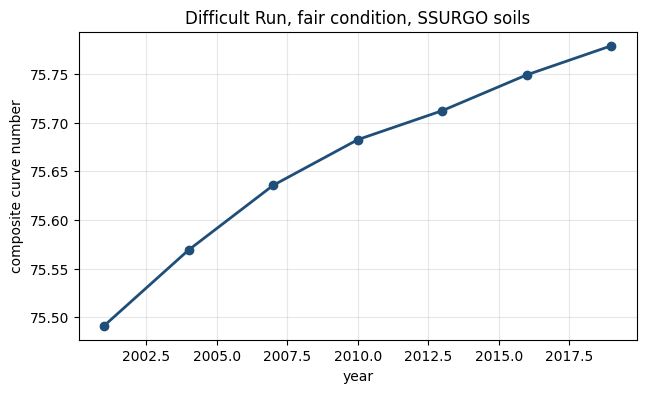

In [8]:
fig, ax = plt.subplots(figsize=(7.2, 4.0))
ax.plot(traj.composite_cn.index, traj.composite_cn.values,
        "o-", color="#1f4e79", lw=2)
ax.set_xlabel("year")
ax.set_ylabel("composite curve number")
ax.set_title("Difficult Run, fair condition, SSURGO soils")
ax.grid(alpha=0.3)
plt.show()

**Figure 1.** Notice the y axis. It spans well under one curve number, so the
autoscale has magnified a rising trend out of a change of about a third of a
unit, and the figure looks like a finding.

## Now the same data, with the assumption drawn around it

Identical numbers, identical axes object, one `fill_between` added: the band
runs from the good condition composite to the poor condition composite, for
the same land cover, in the same year, over the same pixels. Nothing in it was
measured. It is three words in a table.

Expect the trajectory to collapse into a nearly flat line inside a band roughly
7.4 curve numbers tall, and expect the y axis to grow by more than an order of
magnitude relative to Figure 1.

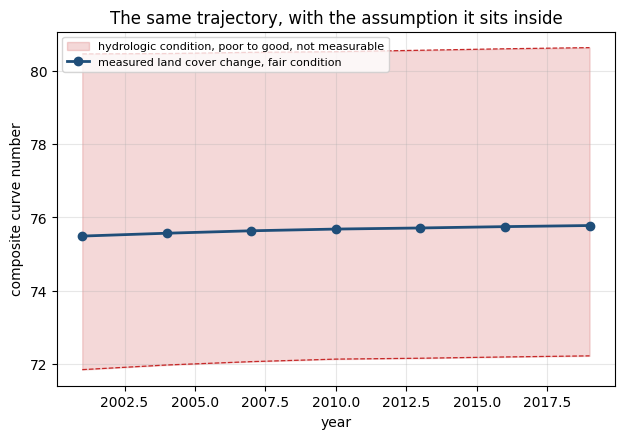

In [9]:
spread = traj.condition_spread

fig, ax = plt.subplots(figsize=(7.2, 4.6))
ax.fill_between(spread.index, spread["good"], spread["poor"],
                color="#c62828", alpha=0.18,
                label="hydrologic condition, poor to good, not measurable")
ax.plot(spread.index, spread["poor"], color="#c62828", lw=0.9, ls="--")
ax.plot(spread.index, spread["good"], color="#c62828", lw=0.9, ls="--")
ax.plot(traj.composite_cn.index, traj.composite_cn.values, "o-",
        color="#1f4e79", lw=2, label="measured land cover change, fair condition")
ax.set_xlabel("year")
ax.set_ylabel("composite curve number")
ax.set_title("The same trajectory, with the assumption it sits inside")
ax.legend(loc="upper left", fontsize=8)
ax.grid(alpha=0.3)
plt.show()

**Figure 2.** Notice that the trajectory of Figure 1 has become a flat line, and
that the band around it is about twenty two times its total height. Every year
of measurement in this figure is smaller than the choice of a single word in a
table.

Two things are worth being precise about here, because the figure invites two
wrong conclusions.

It does **not** say the trajectory is wrong. The land cover measurement is
good, it is reproducible from the provenance below, and it is far better than
what the tabular route can do.

It does **not** say the condition band is an error bar. It is a range of
defensible assumptions, and the fair condition line inside it is a convention,
not a measurement. Nobody can narrow that band with a better satellite, because
the hydrologic condition modifier in the TR-55 soil cover complex tables depends
on ground cover density, litter depth, grazing and compaction, and no Earth
Observation product measures any of them.

What it does say is that a trend statement drawn from the blue line has to be
qualified by the red band, and that reporting the first without the second is
false precision produced faster and at higher resolution than a spreadsheet
could manage.

## What it means in inches

A curve number spread is abstract. The ten year, twenty four hour design storm
is not: 4.78 inches at this gage, from NOAA Atlas 14 Volume 2 Version 3.0. That
depth goes into a pipe size.

`runoff` is `cnkit.core.runoff` evaluated on the composite curve number, which
is the lumped convention. `cnkit.core.composite_runoff` computes runoff per
subarea and then area weights, which is the defensible convention and gives a
larger answer for small storms. Which one goes in the report is an engineering
decision and it should be a conscious one.

Expect, on 4.78 inches of rain: about **2.31 inches** of runoff at fair
condition, about **2.68** at poor, about **2.06** at good. That is a spread of
about **0.62 inches**. Expect the eighteen years of land cover change to be
worth about **0.03 inches** on the same storm.

In [10]:
runoff = traj.runoff_spread
print("design storm: %.2f inches in 24 hours, the 10 year event\n"
      % DESIGN_DEPTH_IN)
runoff.round(4)

design storm: 4.78 inches in 24 hours, the 10 year event



,poor,fair,good,spread
year,,,,
2001,2.7429,2.3129,2.0180,0.7249
2004,2.7438,2.3194,2.0279,0.7159
2007,2.7468,2.3249,2.0352,0.7117
2010,2.7484,2.3288,2.0406,0.7078
2013,2.7519,2.3313,2.0425,0.7094
2016,2.7556,2.3344,2.0452,0.7103
2019,2.7584,2.3369,2.0476,0.7108


In [ ]:
ACRES = 57.8 * 640.0          # square miles to acres

depth_spread = float(runoff.loc[YEARS[-1], "spread"])
depth_change = float(traj.runoff.iloc[-1] - traj.runoff.iloc[0])

print("=" * 66)
print("Difficult Run, 57.8 square miles, 10 year 24 hour storm")
print("-" * 66)
print("condition assumption, poor to good   %7.4f in   %8.0f acre-feet"
      % (depth_spread, depth_spread * ACRES / 12.0))
print("measured %s to %s land cover     %+7.4f in   %+8.0f acre-feet"
      % (YEARS[0], YEARS[-1], depth_change, depth_change * ACRES / 12.0))
print("=" * 66)

In [ ]:
fig, ax = plt.subplots(figsize=(7.2, 4.2))
ax.fill_between(runoff.index, runoff["good"], runoff["poor"],
                color="#c62828", alpha=0.18, label="condition assumption")
ax.plot(traj.runoff.index, traj.runoff.values, "o-", color="#1f4e79", lw=2,
        label="fair condition")
ax.set_xlabel("year")
ax.set_ylabel("runoff depth, inches")
ax.set_title("Runoff from a %.2f inch design storm" % DESIGN_DEPTH_IN)
ax.legend(loc="upper left", fontsize=8)
ax.grid(alpha=0.3)
plt.show()

**Figure 3.** Notice that the same picture survives the translation into
inches: the band is about twenty times the height of the line, and it is the
band, not the line, that would change a pipe diameter.

## Provenance

`provenance` records every asset id, every service, the vintage of each, the
delineation method, the soils choice, the request counts and the quota note.
This is the field that makes the number defensible to a reviewer, and it is why
the workflow is worth using rather than reimplementing.

Expect the Annual NLCD asset to be named with its community catalog path and
its mirror lag, the gNATSGO raster to be named as UNVERIFIED in its vintage
string, Soil Data Access to appear as a service with one query, and the
delineation method to read `nldi_splitcatchment`.

In [11]:
prov = traj.provenance
print(json.dumps(prov["assets"], indent=1, default=str))
print(json.dumps(prov["watershed"], indent=1, default=str))

[
 {
  "id": "projects/sat-io/open-datasets/USGS/ANNUAL_NLCD/LANDCOVER",
  "role": "land cover",
  "catalog": "community",
  "coverage": "CONUS only, no Alaska, Hawaii or Puerto Rico",
  "scale_native_m": 30.0,
  "vintage": "Annual NLCD Collection 1.2. Earth Engine community mirror held the complete 1985 to 2025 land-cover series when queried live on 6 August 2026; collection years are still queried at run time."
 },
 {
  "id": "projects/sat-io/open-datasets/gNATSGO/raster/mukey",
  "role": "hydrologic soil group",
  "catalog": "community raster, authoritative tabular",
  "coverage": "United States and island territories",
  "scale_native_m": 30.0,
  "vintage": "gNATSGO gridded map unit keys, community mirror of the Microsoft Planetary Computer national distribution, generally available October 2024, implying a 2021 to 2023 gNATSGO vintage. NRCS refreshes gNATSGO annually, so the mirror drifts. UNVERIFIED."
 }
]
{
 "method": "nldi_splitcatchment",
 "source_dataset": "NHDPlusV2",
 "area

In [12]:
engine = prov["earth_engine"]
print("Earth Engine requests issued          ", engine["requests_issued"])
print("served from the per call memo         ", engine["requests_served_from_cache"])
print("scale, metres                         ", engine["scale_m"])
print()
for service in prov["services"]:
    print("%-42s %s" % (service["name"], service.get("endpoint")))

Earth Engine requests issued           8
served from the per call memo          14
scale, metres                          30.0

Google Earth Engine                        https://earthengine.googleapis.com
USDA Soil Data Access                      https://sdmdataaccess.nrcs.usda.gov/Tabular/post.rest
USGS NLDI split catchment process          https://api.water.usgs.gov/nldi


Saving the whole result is one call, and the provenance is JSON serialisable,
so the table and the story of how it was made can travel together.

In [13]:
frame.to_csv("difficult_run_cn_trajectory.csv")
with open("difficult_run_cn_provenance.json", "w", encoding="utf-8") as handle:
    json.dump(prov, handle, indent=1, default=str)
print("wrote difficult_run_cn_trajectory.csv and "
      "difficult_run_cn_provenance.json")

wrote difficult_run_cn_trajectory.csv and difficult_run_cn_provenance.json


## What to take from this

- Earth Observation has made the curve number measurable, spatially resolved
  and reproducible. Notebook 1 got a boundary that matches a published drainage
  area to a tenth of a percent, notebook 2 removed an independence assumption
  worth 4.5 curve numbers, and this one measured eighteen years of land cover
  change at 30 m.
- The measurement is 0.34 curve numbers. The hydrologic condition assumption
  sitting on top of it is 7.43. Better inputs did not touch that, and no better
  satellite will, because the condition is not an observable.
- So the remaining error is dominated by the 1954 equation and its tables, not
  by the inputs. That is the argument this library is built around, and Figure
  2 is it.
- Publish the band with the line. `CnTrajectory` carries
  `condition_spread` as a required field and `spread_to_change_ratio` as a
  number precisely so that the comparison is available without anybody having to
  think of making it.
- If the ratio is above one, any statement about trend has to be qualified by
  it. On this basin it is about twenty two.

There is no warranty on any of this. Verify before you design anything.